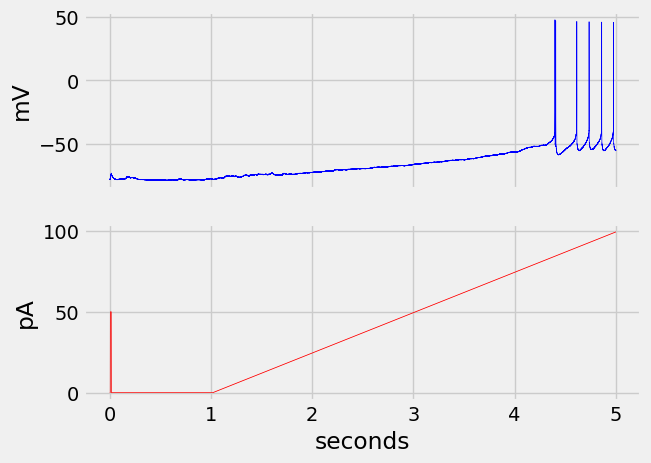

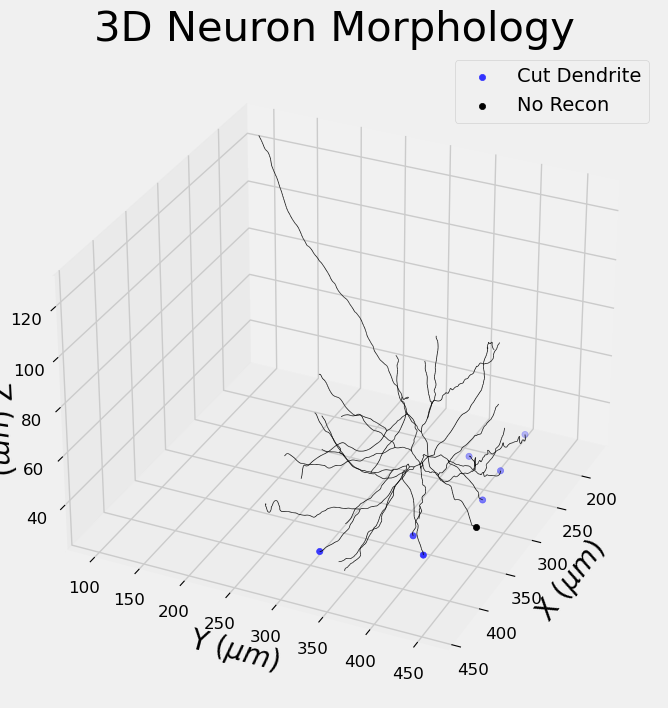

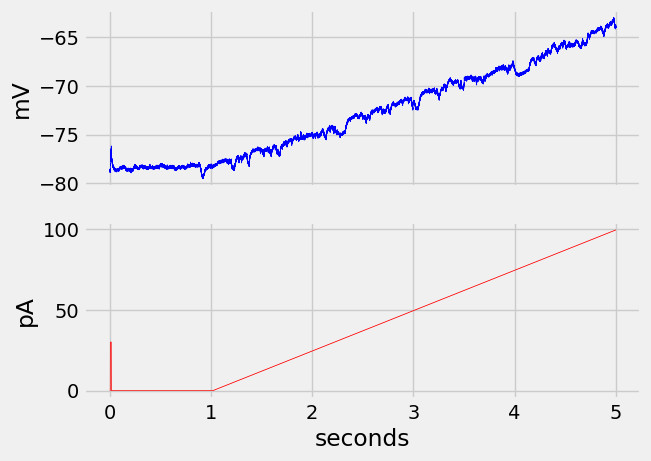

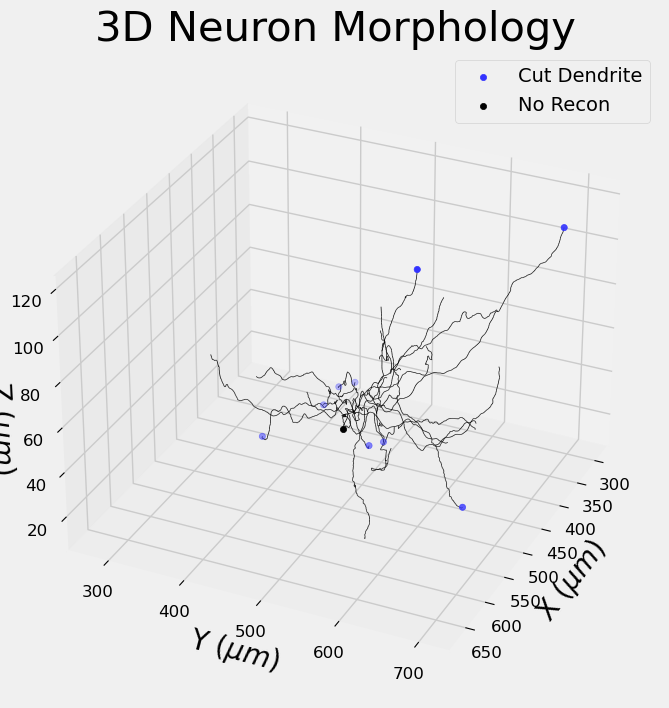

In [1]:
from plot_data import plot_data, plot_morphology, plot_morphology_3D
from pathlib import Path
import os
import matplotlib.pyplot as plt
plot_data(422738880, 4, 0, 5)
plot_morphology_3D(422738880)

plot_data(469801569, 4, 0, 5)
plot_morphology_3D(469801569)




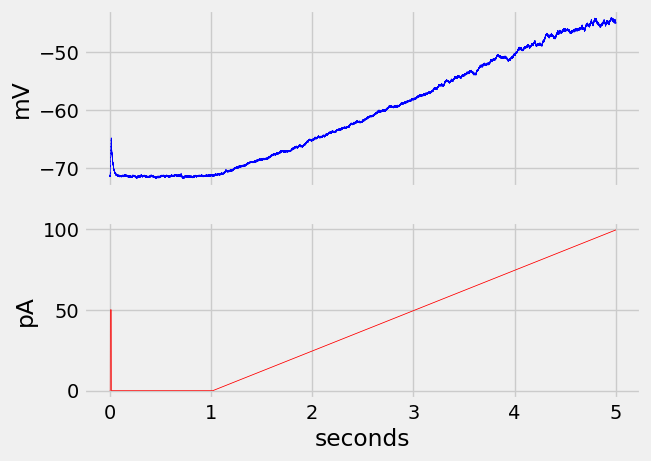

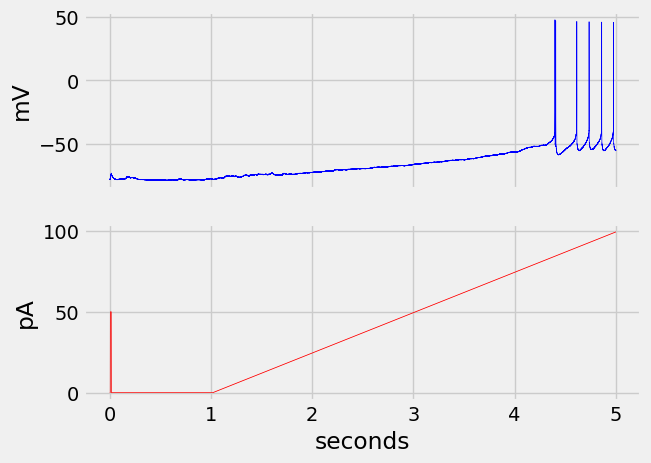

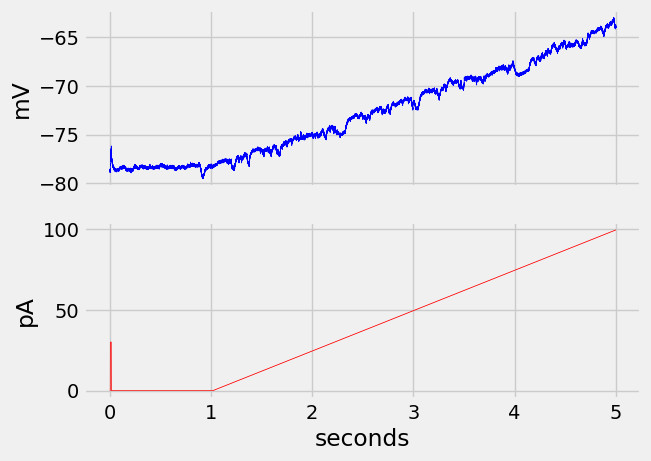

array([<Axes: ylabel='mV'>, <Axes: xlabel='seconds', ylabel='pA'>],
      dtype=object)

In [6]:
plot_data(475623964, 4, 0, 5)

plot_data(422738880, 4, 0, 5)

plot_data(469801569, 4, 0, 5)


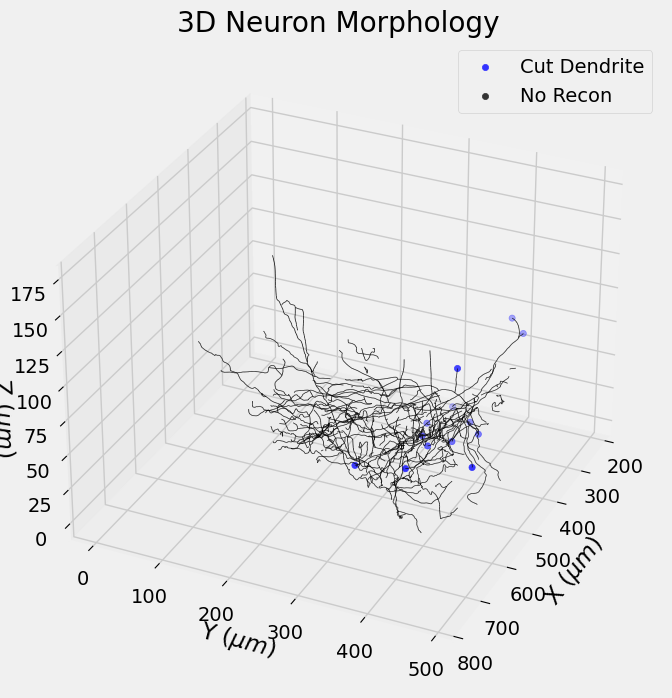

In [16]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from allensdk.core.swc import Marker
from allensdk.core.cell_types_cache import CellTypesCache

ctc = CellTypesCache(manifest_file='cell_types/manifest.json')
morphology = ctc.get_reconstruction(cell_id) 
markers = ctc.get_reconstruction_markers(cell_id) 
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 1. Draw the morphology (neuronal tree)
for n in morphology.compartment_list:
    for c in morphology.children_of(n):
        ax.plot([n['x'], c['x']], 
                [n['y'], c['y']], 
                [n['z'], c['z']], color='black', lw=0.5)

# 2. Plot Cut Dendrite markers
dm = [m for m in markers if m['name'] == Marker.CUT_DENDRITE]
ax.scatter([m['x'] for m in dm], 
           [m['y'] for m in dm], 
           [m['z'] for m in dm], color='#3333ff', s=20, label='Cut Dendrite')

# 3. Plot No Reconstruction markers
nm = [m for m in markers if m['name'] == Marker.NO_RECONSTRUCTION]
ax.scatter([m['x'] for m in nm], 
           [m['y'] for m in nm], 
           [m['z'] for m in nm], color='#333333', s=20, label='No Recon')
# Formatting
ax.set_xlabel('X ($\mu m$)')
ax.set_ylabel('Y ($\mu m$)')
ax.set_zlabel('Z ($\mu m$)')
ax.set_title('3D Neuron Morphology')
plt.legend()
ax.view_init(elev=30, azim=25)
plt.show()